In [1]:
import os 
import cv2
import json
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import warnings 
warnings.filterwarnings('ignore')

from collections import defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from keras.models import Model
from keras.layers import Layer
from keras.layers import Conv2D
from keras.layers import Dropout
from keras.layers import UpSampling2D
from keras.layers import concatenate
from keras.layers import Add
from keras.layers import Multiply
from keras.layers import Input
from keras.layers import MaxPool2D
from keras.layers import BatchNormalization

from IPython.display import clear_output
!pip install tf_explain
clear_output()

from keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from tf_explain.core.grad_cam import GradCAM

from keras.metrics import MeanIoU

In [2]:
BASE_PATH = "/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset"
data = []

# Grades
for grade in ["Grade_1", "Grade_2", "Grade_3"]:
    
    radiology_dir = os.path.join(BASE_PATH, grade, "Radiology")
    masks_dir = os.path.join(BASE_PATH, grade, "Masks")
    
    radiology_files = os.listdir(radiology_dir)
    
    for radiology_file in radiology_files:
        
        if not radiology_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
    
        image_id = os.path.splitext(radiology_file)[0]
        
        mask_file = image_id + ".png"
        mask_path = os.path.join(masks_dir, mask_file)
        
        radiology_path = os.path.join(radiology_dir, radiology_file)
        
        if os.path.exists(mask_path):
            
            data.append({
                "image_path": radiology_path,
                "mask_path": mask_path,
                "label": grade
            })

df = pd.DataFrame(data)

print("Number of samples:", len(df))
df.head()

Number of samples: 2031


,image_path,mask_path,label
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1


In [3]:
df.shape

(2031, 3)

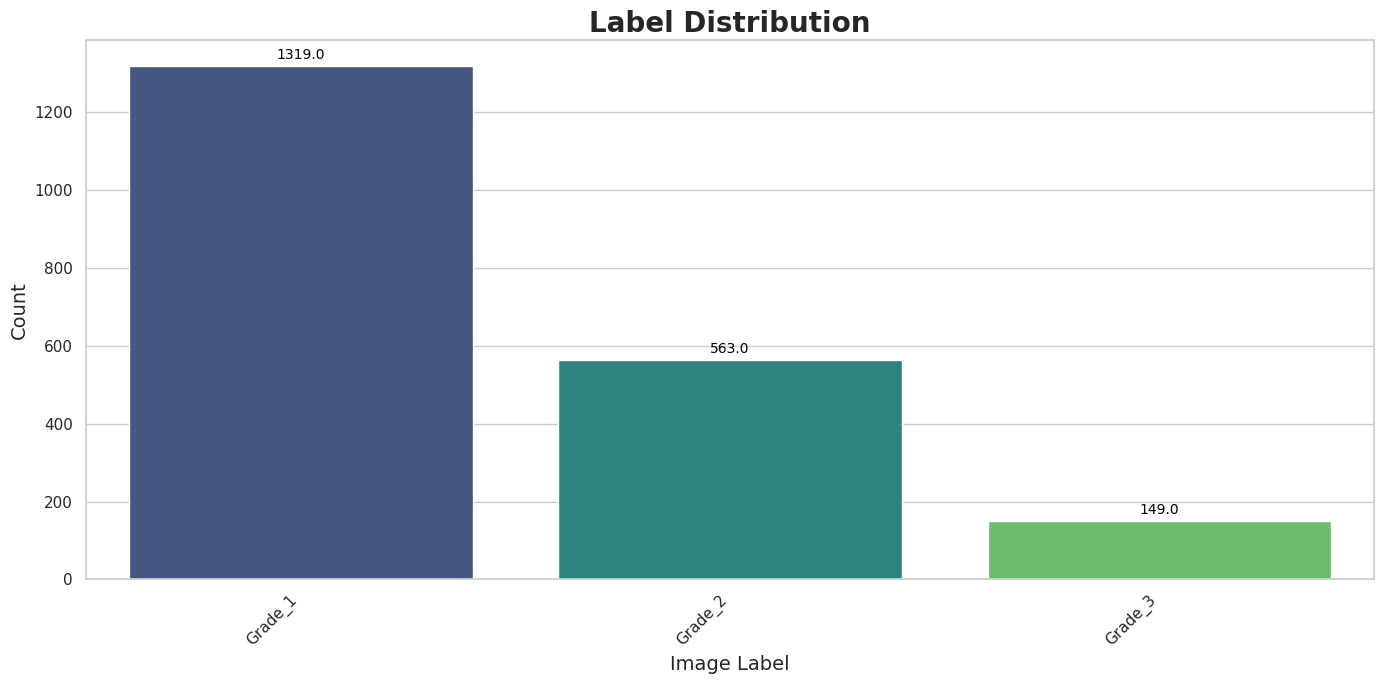

In [4]:
# Set style
sns.set(style="whitegrid")

# Create the figure
plt.figure(figsize=(14, 7))

# Plot count of Image_Label column
ax = sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)

# Set labels and title
plt.title("Label Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Image Label", fontsize=14)
plt.ylabel("Count", fontsize=14)

# Rotate x labels if needed
plt.xticks(rotation=45, ha='right')

# Annotate counts on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                textcoords='offset points')
plt.tight_layout()
plt.show()

In [5]:
df_grade1 = df[df['label']=='Grade_1'].head(1)
df_grade2 = df[df['label']=='Grade_2'].head(1)
df_grade3 = df[df['label']=='Grade_3'].head(1)

In [6]:
df_grade1

,image_path,mask_path,label
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1


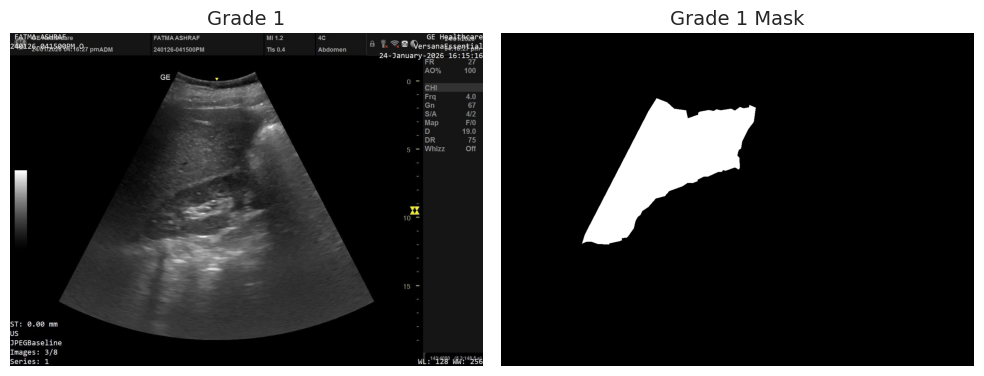

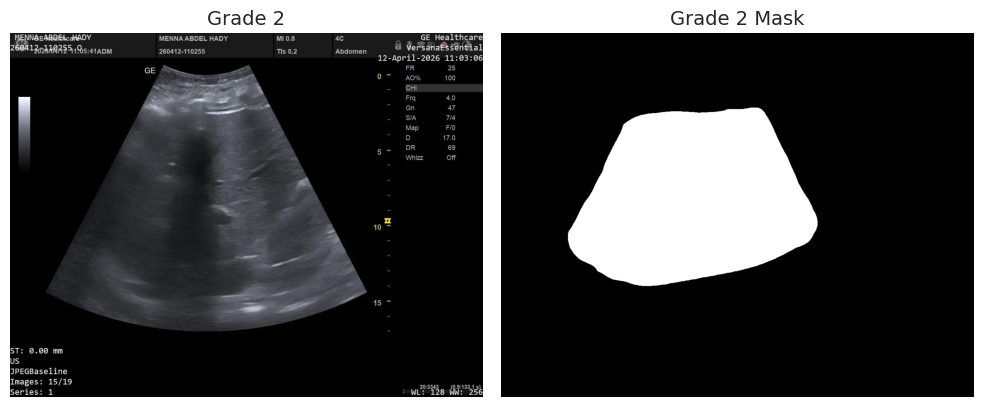

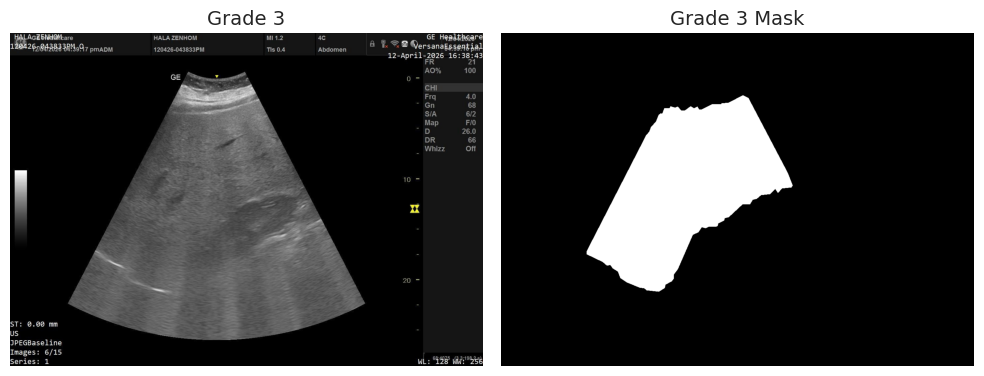

In [7]:
grades = {
    "Grade 1": df_grade1,
    "Grade 2": df_grade2,
    "Grade 3": df_grade3
}

for grade_name, df_grade in grades.items():

    plt.figure(figsize=(10, 5))
    row = df_grade.iloc[0]
    img = Image.open(row["image_path"])
    mask_path = row["mask_path"]

    if isinstance(mask_path, str):
        mask = Image.open(mask_path)
    else:
        mask = None
        
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(grade_name, fontsize=14)
    plt.subplot(1, 2, 2)

    if mask is not None:
        plt.imshow(mask, cmap="gray")
        plt.title(f"{grade_name} Mask", fontsize=14)
    else:
        plt.title("No Mask")

    plt.axis("off")

    plt.tight_layout()
    plt.show()

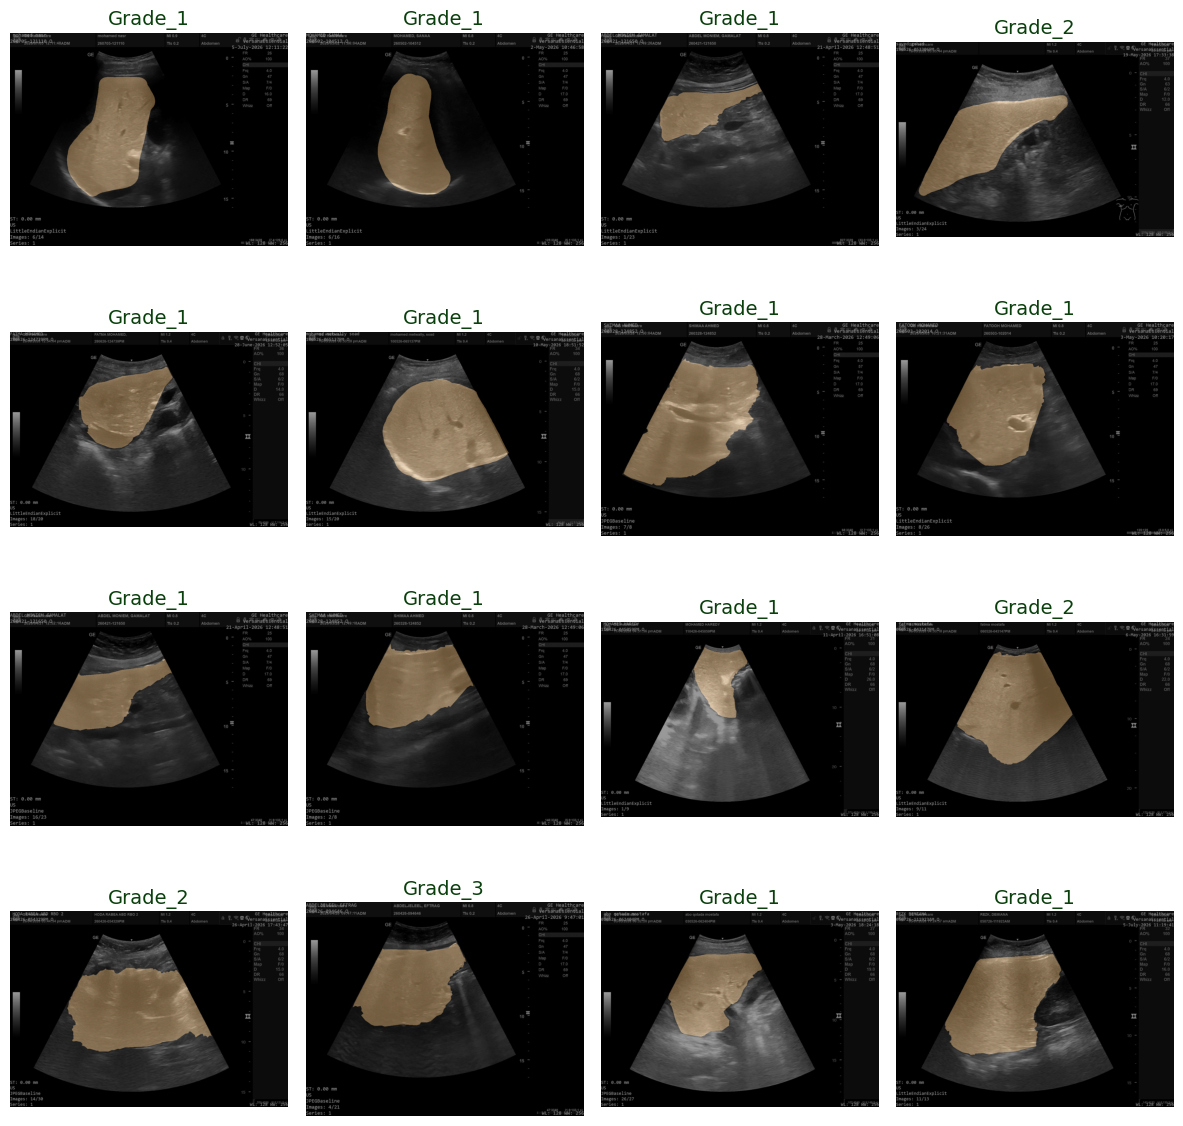

In [8]:
# Shuffle dataframe
df = df.sample(frac=1).reset_index(drop=True)

# Plot first 16 samples
plt.figure(figsize=(12, 12))

for i in range(16):

    # -------------------------
    # Load image
    # -------------------------
    img_path = df.iloc[i]['image_path']
    img = np.array(Image.open(img_path).convert("L"))

    # -------------------------
    # Load mask
    # -------------------------
    mask_path = df.iloc[i]['mask_path']

    if isinstance(mask_path, list) and len(mask_path) > 0:
        mask_path = mask_path[0]

    if mask_path is not None:
        mask = np.array(Image.open(mask_path).convert("L"))
    else:
        mask = None

    # -------------------------
    # Plot
    # -------------------------
    plt.subplot(4, 4, i + 1)

    # Original image
    plt.imshow(img, cmap="gray")

    # Mask overlay
    if mask is not None:
        plt.imshow(mask, cmap="copper", alpha=0.4)
    label_name = df.iloc[i]['label']
    plt.title(label_name, color='#0A400C', fontsize=14)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
batchsize    = 32
image_height = 224
image_width  = 224
num_classes  = 3
epochs       = 200

In [10]:
def load_image_mask(image_path, mask_path):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        (image_height, image_width)
    )
    image = tf.cast(image, tf.float32) / 255.0
    mask = tf.io.read_file(mask_path)

    mask = tf.image.decode_image(
        mask,
        channels=1,
        expand_animations=False
    )

    mask = tf.image.resize(
        mask,
        (image_height, image_width),
        method="nearest"
    )
    mask = tf.cast(mask, tf.float32) / 255.0


    return image, mask

In [11]:
train_df, validation_df = train_test_split(
    df,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=df['label']
)

In [12]:
print("Train:", len(train_df))
print("Validation:", len(validation_df))

print("\nTrain distribution:")
print(train_df['label'].value_counts(normalize=True))

print("\nValidation distribution:")
print(validation_df['label'].value_counts(normalize=True))

Train: 1827
Validation: 204

Train distribution:
label
Grade_1    0.649699
Grade_2    0.276957
Grade_3    0.073344
Name: proportion, dtype: float64

Validation distribution:
label
Grade_1    0.647059
Grade_2    0.279412
Grade_3    0.073529
Name: proportion, dtype: float64


In [13]:
class_names = sorted(df['label'].unique())
class_to_idx = {
    name: idx for idx, name in enumerate(class_names)
}
train_df['label_id'] = train_df['label'].map(class_to_idx)
validation_df['label_id'] = validation_df['label'].map(class_to_idx)

In [14]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df['image_path'].values,
        train_df['mask_path'].values,
        #train_df['label_id'].values
    )
)

train_ds = train_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

I0000 00:00:1790443231.637600      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790443231.640342      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [15]:
train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    seed=42
)

train_ds = train_ds.batch(batchsize)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

In [16]:
validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        validation_df['image_path'].values,
        validation_df['mask_path'].values,
        #validation_df['label_id'].values
    )
)

validation_ds = validation_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.batch(batchsize)

validation_ds = validation_ds.prefetch(
    tf.data.AUTOTUNE
)

In [17]:
def augment(image, mask):
    seed = tf.random.uniform(
        [2],
        maxval=100000,
        dtype=tf.int32
    )

    image = tf.image.stateless_random_flip_left_right(
        image,
        seed=seed
    )

    mask = tf.image.stateless_random_flip_left_right(
        mask,
        seed=seed
    )

    return image, mask

In [18]:
train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [19]:
class EncoderBlock(Layer):
    def __init__(self,filters,rate,pooling=True,**kwargs):
        super(EncoderBlock,self).__init__(**kwargs)

        self.filters = filters
        self.rate    = rate
        self.pooling = pooling
        self.c1      = Conv2D(filters,kernel_size = 3,strides=1,padding='same',activation='relu',kernel_initializer='he_normal')
        self.drop    = Dropout(rate)
        self.c2      = Conv2D(filters,kernel_size = 3,strides=1,padding='same',activation='relu',kernel_initializer='he_normal')
        self.pool    = MaxPool2D()

    def call(self,x):
        x = self.c1(x)
        x = self.drop(x)
        x = self.c2(x)
        if self.pooling:
            y = self.pool(x)
            return y,x

        else :
            return x
    def get_config(self):
        base_config = super().get_config()
        return{
            **base_config,
            "filters" : self.filters,
             "rate"   : self.rate,
            "pooling" : self.pooling
        }

In [20]:
class DecoderBlock(Layer):

    def __init__(self, filters, rate, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)

        self.filters = filters
        self.rate = rate

        self.up = UpSampling2D()
        self.net = EncoderBlock(filters, rate, pooling=False)

    def call(self, X):
        X, skip_X = X
        x = self.up(X)
        c_ = concatenate([x, skip_X])
        x = self.net(c_)
        return x

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "filters":self.filters,
            'rate':self.rate,
        }

In [21]:
class AttentionGate(Layer):

    def __init__(self, filters, bn, **kwargs):
        super(AttentionGate, self).__init__(**kwargs)

        self.filters = filters
        self.bn = bn

        self.normal = Conv2D(filters, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal')
        self.down = Conv2D(filters, kernel_size=3, strides=2, padding='same', activation='relu', kernel_initializer='he_normal')
        self.learn = Conv2D(1, kernel_size=1, padding='same', activation='sigmoid')
        self.resample = UpSampling2D()
        self.BN = BatchNormalization()

    def call(self, X):
        X, skip_X = X

        x = self.normal(X)
        skip = self.down(skip_X)
        x = Add()([x, skip])
        x = self.learn(x)
        x = self.resample(x)
        f = Multiply()([x, skip_X])
        if self.bn:
            return self.BN(f)
        else:
            return f
    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "filters":self.filters,
            "bn":self.bn
        }

In [22]:
def show_image(image, title=None, cmap=None, alpha=1):
    plt.imshow(image, cmap=cmap, alpha=alpha)
    if title is not None:
        plt.title(title)
    plt.axis('off')

def show_mask(image, mask, cmap=None, alpha=0.4):
    plt.imshow(image)
    plt.imshow(tf.squeeze(mask), cmap=cmap, alpha=alpha)
    plt.axis('off')

In [23]:
class ShowProgress(Callback):

    def on_epoch_end(self, epoch, logs=None):

        # Get one batch from validation dataset
        images, masks = next(iter(validation_ds))

        # Pick random image from the batch
        idx = np.random.randint(0, images.shape[0])

        image = images[idx]
        true_mask = masks[idx]

        # Prediction
        pred_mask = self.model.predict(
            tf.expand_dims(image, axis=0),
            verbose=0
        )[0]

        # Convert prediction to binary mask
        pred_mask = (pred_mask > 0.5).astype(np.float32)
        plt.figure(figsize=(15, 5))

        # Original image
        plt.subplot(1, 3, 1)
        show_image(
            image,
            title=f"Image - Epoch {epoch + 1}"
        )

        # Ground Truth
        plt.subplot(1, 3, 2)
        show_mask(
            image,
            true_mask,
            cmap="copper"
        )
        plt.title("Ground Truth")

        # Prediction
        plt.subplot(1, 3, 3)
        show_mask(
            image,
            pred_mask,
            cmap="copper"
        )
        plt.title("Prediction")

        plt.tight_layout()
        plt.show()

In [24]:
# Inputs
input_layer = Input(
    shape=(image_height, image_width, 3)
)

# Encoder
p1, c1 = EncoderBlock(32,0.1, name="Encoder1")(input_layer)
p2, c2 = EncoderBlock(64,0.1, name="Encoder2")(p1)
p3, c3 = EncoderBlock(128,0.2, name="Encoder3")(p2)
p4, c4 = EncoderBlock(256,0.2, name="Encoder4")(p3)

# Encoding
encoding = EncoderBlock(512,0.3, pooling=False, name="Encoding")(p4)

# Attention + Decoder

a1 = AttentionGate(256, bn=True, name="Attention1")([encoding, c4])
d1 = DecoderBlock(256,0.2, name="Decoder1")([encoding, a1])

a2 = AttentionGate(128, bn=True, name="Attention2")([d1, c3])
d2 = DecoderBlock(128,0.2, name="Decoder2")([d1, a2])

a3 = AttentionGate(64, bn=True, name="Attention3")([d2, c2])
d3 = DecoderBlock(64,0.1, name="Decoder3")([d2, a3])


a4 = AttentionGate(32, bn=True, name="Attention4")([d3, c1])
d4 = DecoderBlock(32,0.1, name="Decoder4")([d3, a4])

# Output 
output_layer = Conv2D(
    1,
    kernel_size=1,
    activation="sigmoid",
    padding="same",
    name="segmentation_output"
)(d4)

# Model
model = Model(
    inputs=[input_layer],
    outputs=[output_layer]
)

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', MeanIoU(num_classes=2, name='IoU')]
)

# Callbacks
cb = [
    # EarlyStopping(patience=3, restore_best_weight=True), # With Segmentation I trust on eyes rather than on metrics
    ModelCheckpoint("AttentionCustomUNet.h5", save_best_only=True),
    ShowProgress()
]

Epoch 1/20


2026-09-26 17:21:15.940125: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:21:16.244720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:21:16.467538: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[32,32,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,224,224]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0}

57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - IoU: 0.4293 - accuracy: 0.8503 - loss: 3.4266

2026-09-26 17:23:01.936749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:23:02.221129: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:23:03.241364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:23:03.541121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-26 17:23:03.977634: E external/local_xla/xla/stream_

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - IoU: 0.4293 - accuracy: 0.8506 - loss: 3.3868   

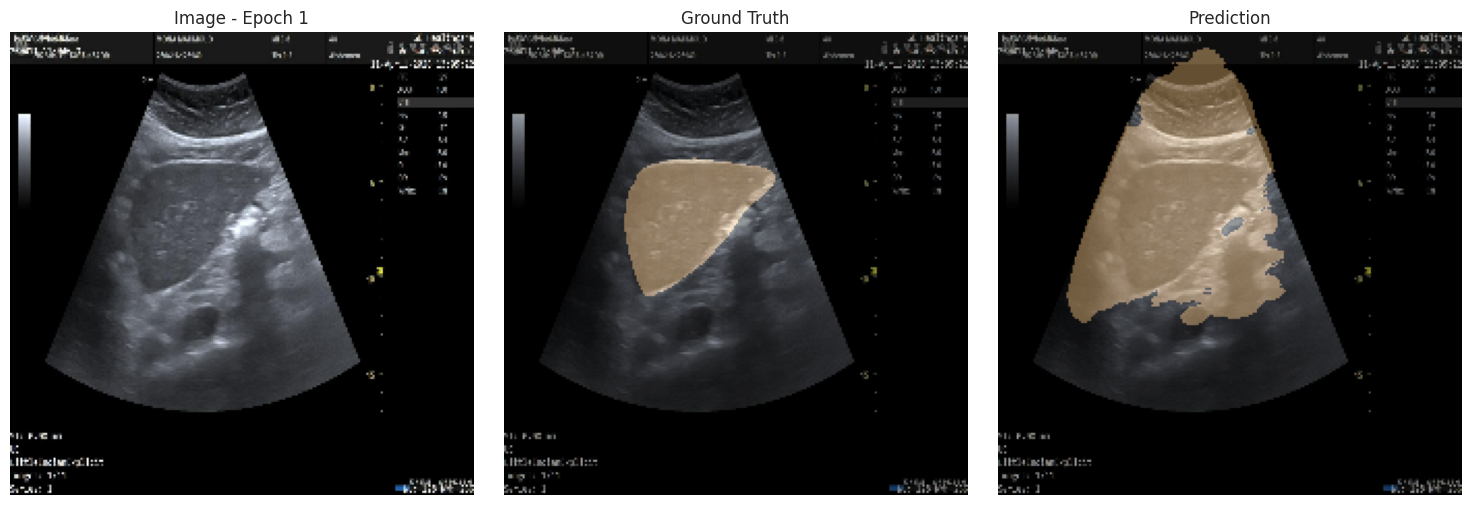

58/58 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - IoU: 0.4294 - accuracy: 0.8690 - loss: 1.1185 - val_IoU: 0.4314 - val_accuracy: 0.8950 - val_loss: 0.2900
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - IoU: 0.4310 - accuracy: 0.9185 - loss: 0.1736

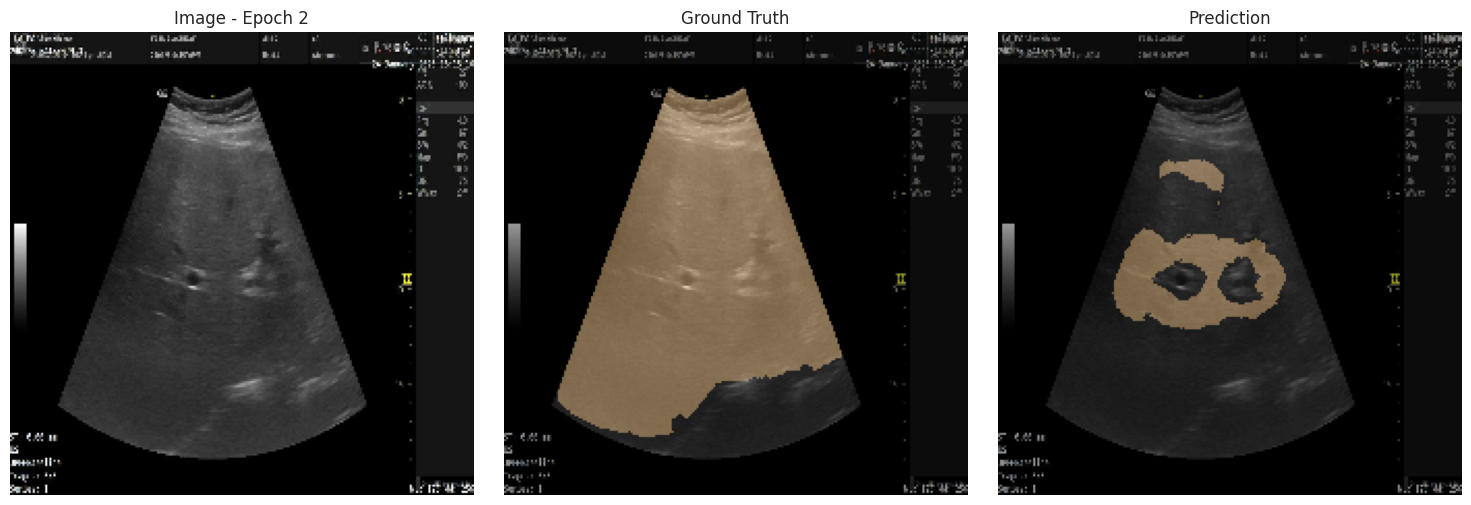

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 711ms/step - IoU: 0.4294 - accuracy: 0.9222 - loss: 0.1729 - val_IoU: 0.4314 - val_accuracy: 0.8959 - val_loss: 0.1957
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - IoU: 0.4295 - accuracy: 0.9322 - loss: 0.1517

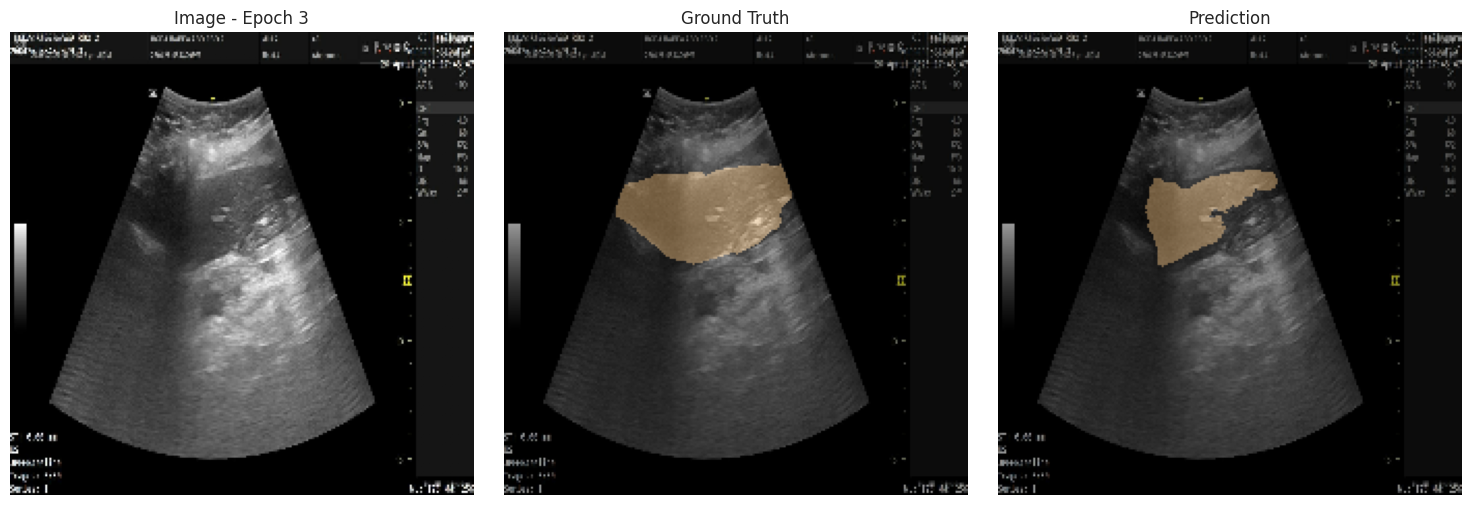

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 715ms/step - IoU: 0.4294 - accuracy: 0.9330 - loss: 0.1545 - val_IoU: 0.4314 - val_accuracy: 0.8988 - val_loss: 0.3236
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - IoU: 0.4310 - accuracy: 0.9395 - loss: 0.1455

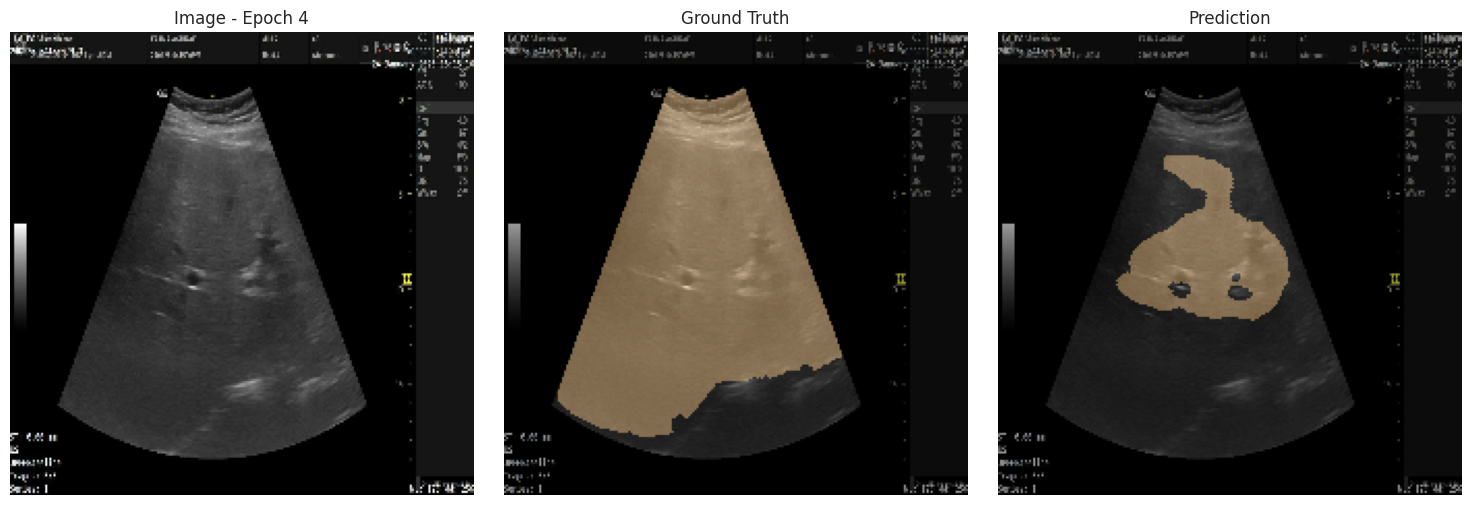

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 716ms/step - IoU: 0.4294 - accuracy: 0.9378 - loss: 0.1458 - val_IoU: 0.4314 - val_accuracy: 0.9105 - val_loss: 0.1861
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - IoU: 0.4290 - accuracy: 0.9400 - loss: 0.1410

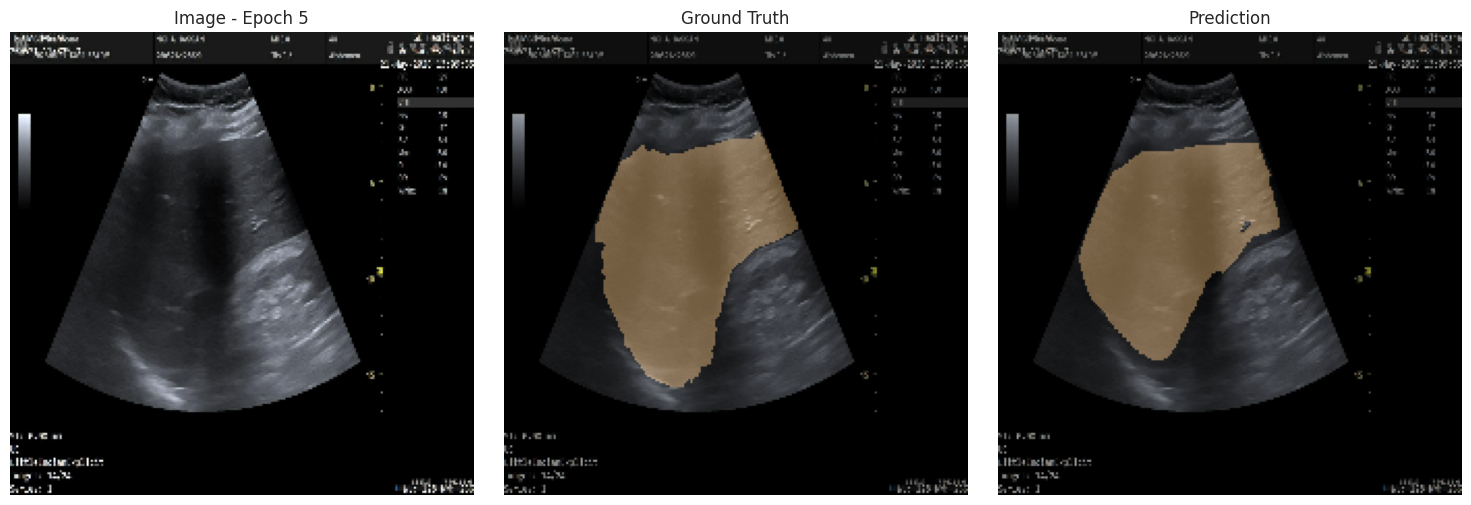

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 718ms/step - IoU: 0.4294 - accuracy: 0.9424 - loss: 0.1343 - val_IoU: 0.4314 - val_accuracy: 0.9327 - val_loss: 0.1514
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - IoU: 0.4279 - accuracy: 0.9466 - loss: 0.1270

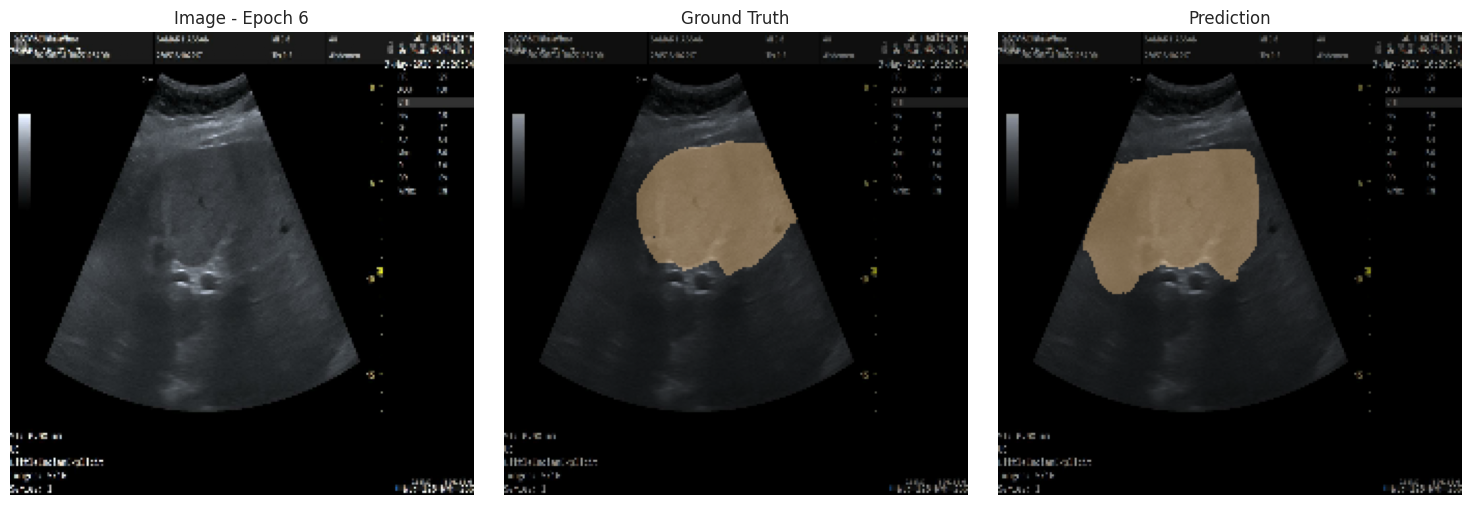

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 712ms/step - IoU: 0.4294 - accuracy: 0.9469 - loss: 0.1282 - val_IoU: 0.4314 - val_accuracy: 0.9400 - val_loss: 0.1540
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - IoU: 0.4272 - accuracy: 0.9472 - loss: 0.1324

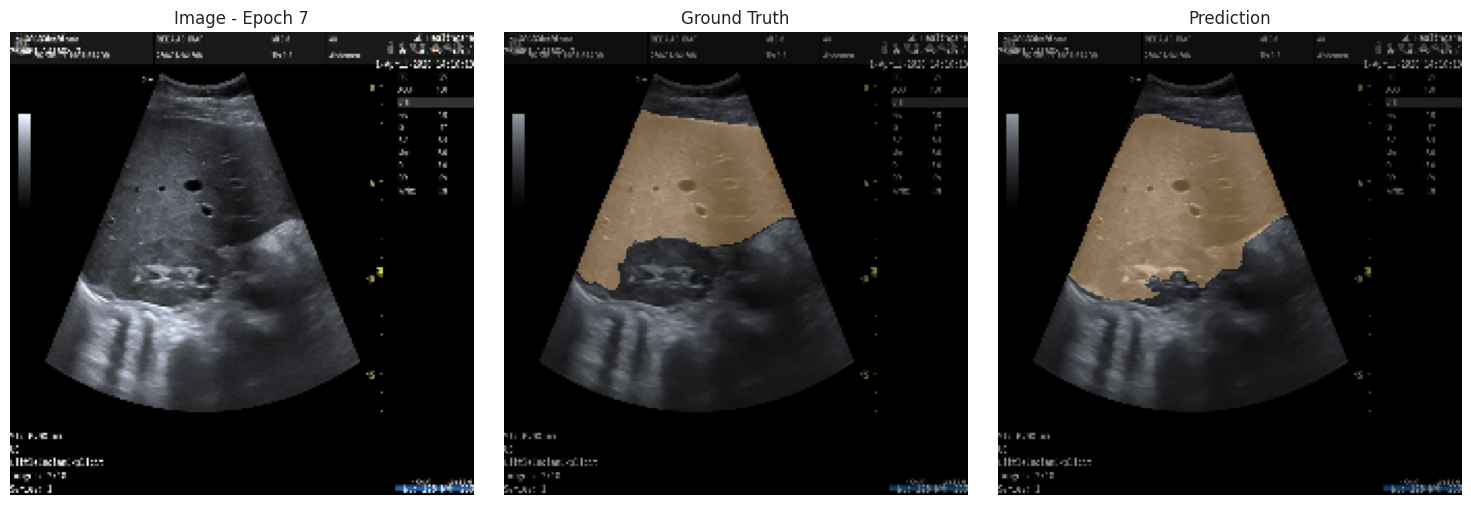

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 720ms/step - IoU: 0.4294 - accuracy: 0.9496 - loss: 0.1212 - val_IoU: 0.4314 - val_accuracy: 0.9497 - val_loss: 0.1313
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - IoU: 0.4296 - accuracy: 0.9500 - loss: 0.1223

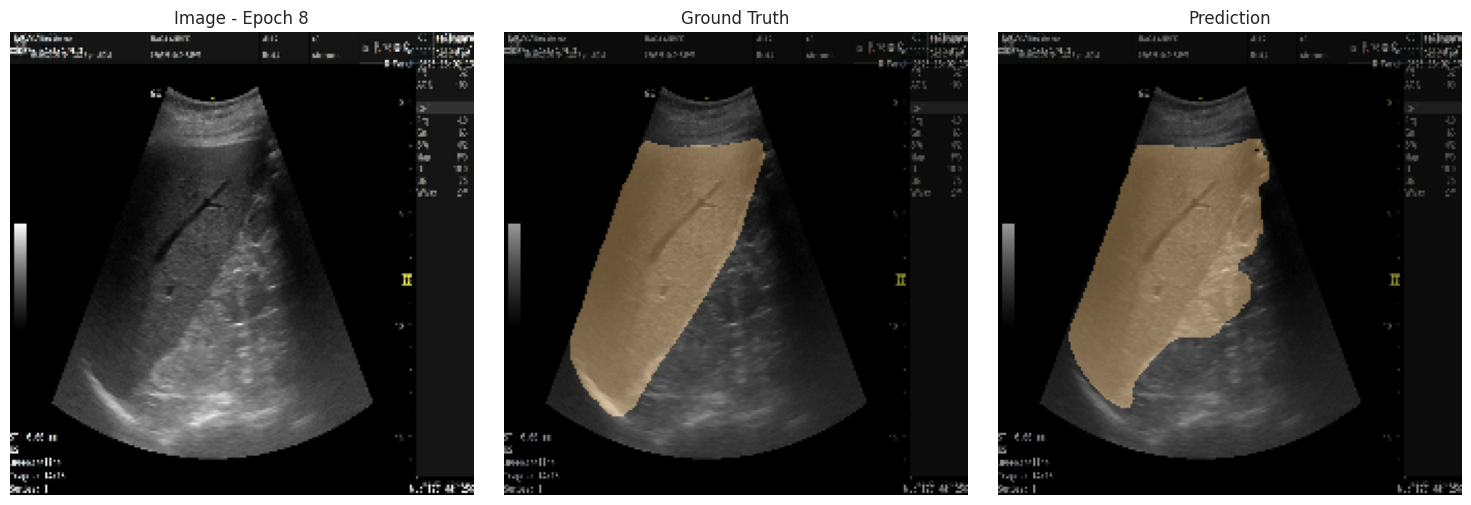

58/58 ━━━━━━━━━━━━━━━━━━━━ 49s 721ms/step - IoU: 0.4294 - accuracy: 0.9509 - loss: 0.1183 - val_IoU: 0.4314 - val_accuracy: 0.9482 - val_loss: 0.1225
Epoch 9/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - IoU: 0.4297 - accuracy: 0.9520 - loss: 0.1175

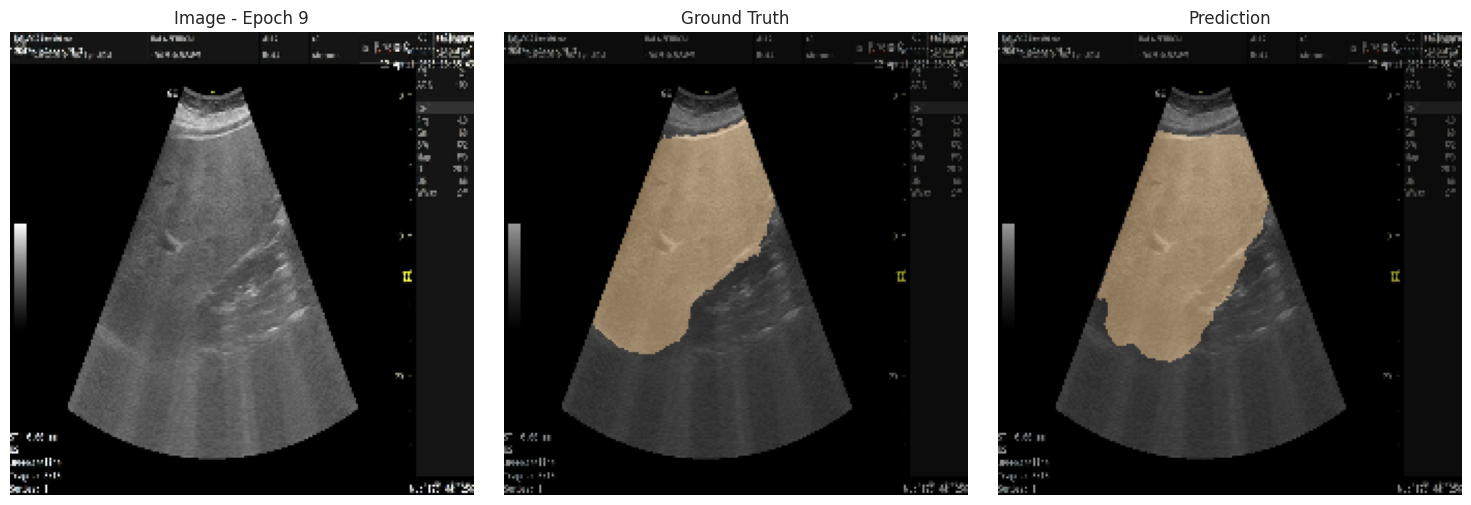

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 713ms/step - IoU: 0.4294 - accuracy: 0.9521 - loss: 0.1156 - val_IoU: 0.4314 - val_accuracy: 0.9471 - val_loss: 0.1354
Epoch 10/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - IoU: 0.4293 - accuracy: 0.9505 - loss: 0.1248

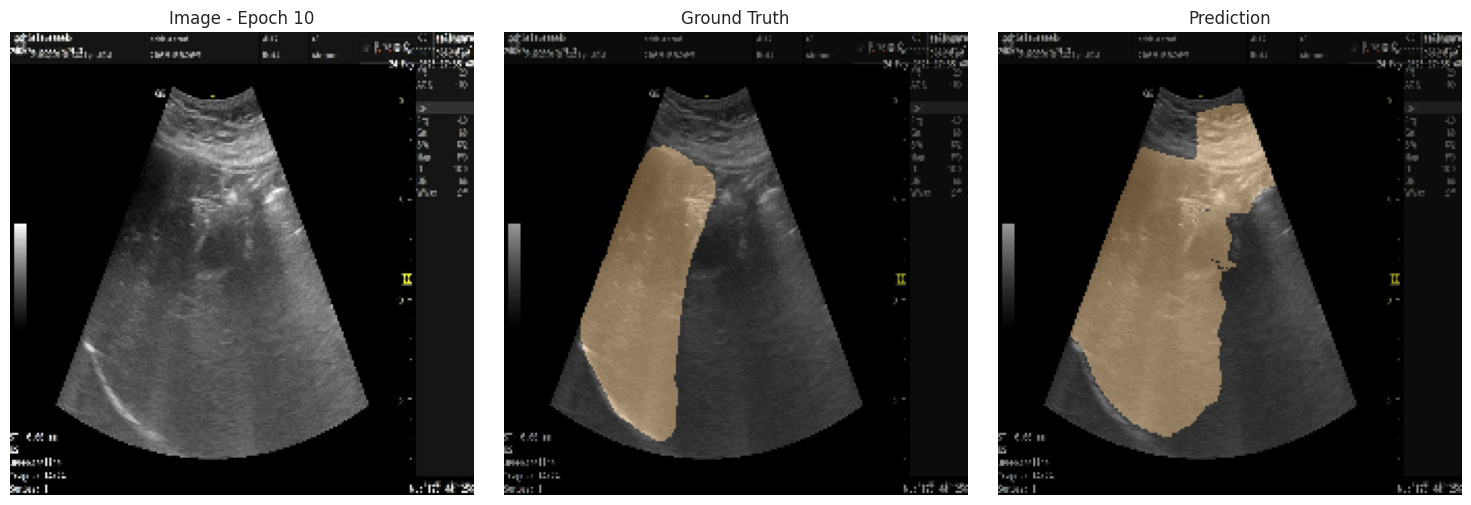

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 721ms/step - IoU: 0.4294 - accuracy: 0.9535 - loss: 0.1119 - val_IoU: 0.4314 - val_accuracy: 0.9513 - val_loss: 0.1173
Epoch 11/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - IoU: 0.4296 - accuracy: 0.9541 - loss: 0.1138

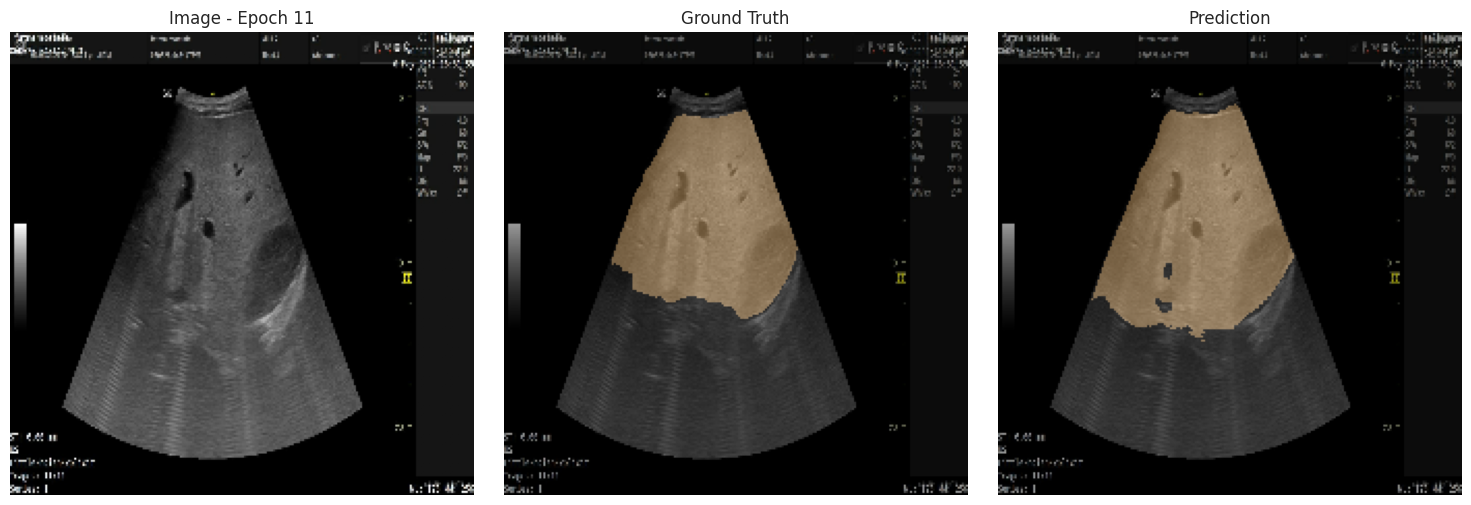

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 722ms/step - IoU: 0.4294 - accuracy: 0.9552 - loss: 0.1096 - val_IoU: 0.4314 - val_accuracy: 0.9504 - val_loss: 0.1168
Epoch 12/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - IoU: 0.4289 - accuracy: 0.9529 - loss: 0.1187

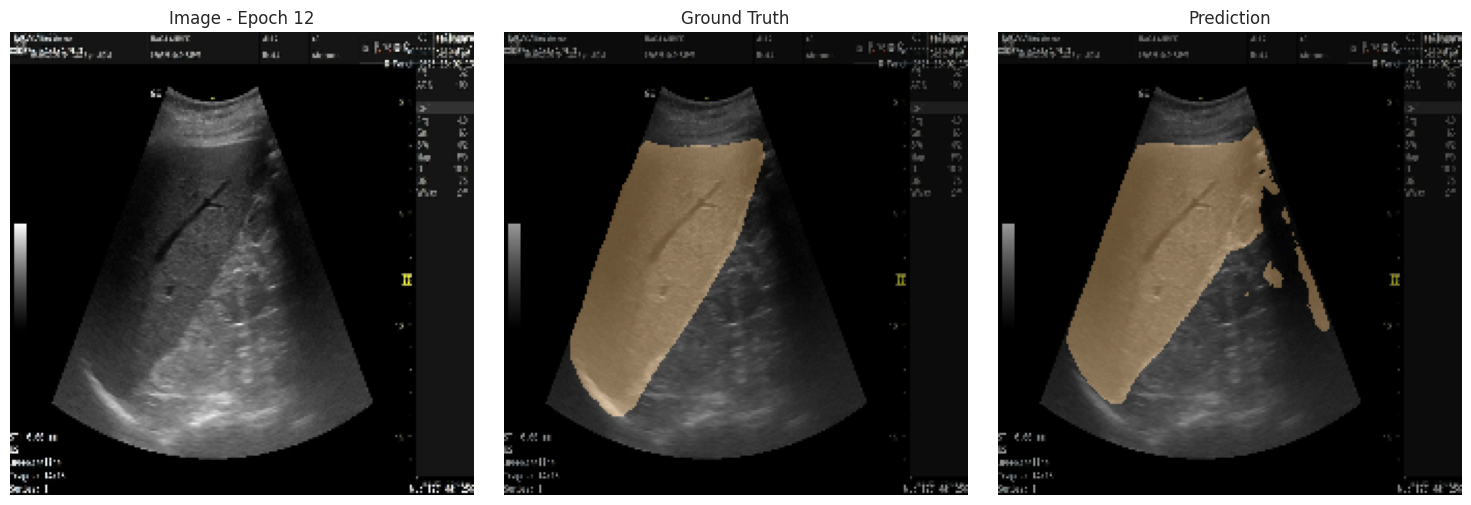

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 717ms/step - IoU: 0.4294 - accuracy: 0.9548 - loss: 0.1098 - val_IoU: 0.4314 - val_accuracy: 0.9532 - val_loss: 0.1099
Epoch 13/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - IoU: 0.4297 - accuracy: 0.9572 - loss: 0.1067

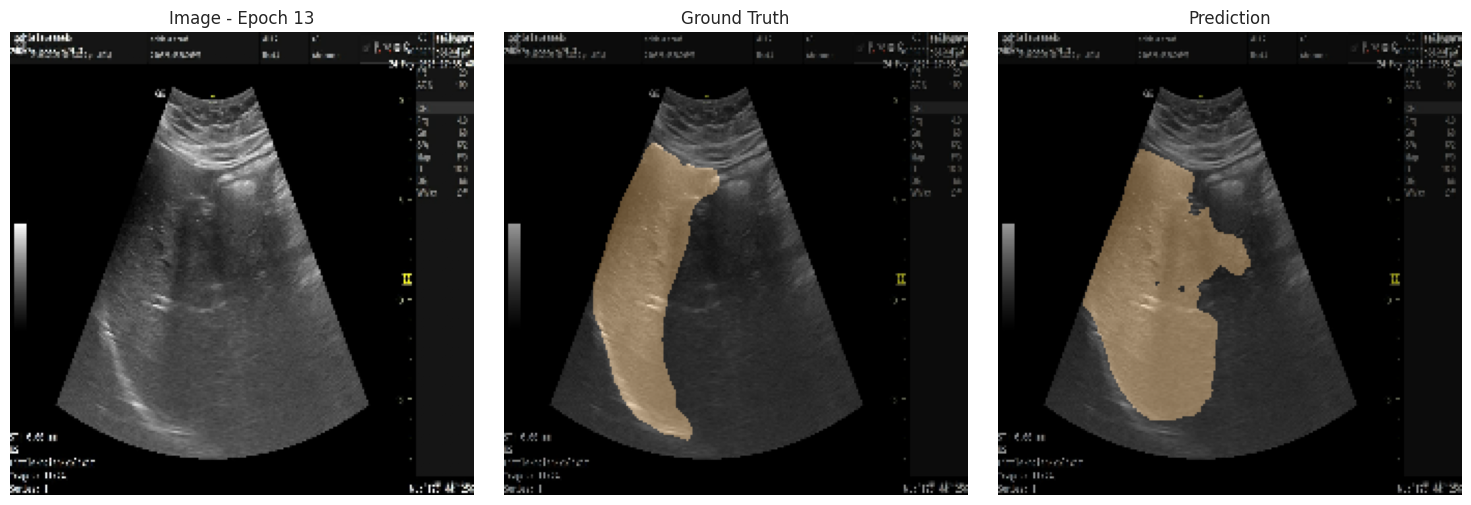

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 720ms/step - IoU: 0.4294 - accuracy: 0.9570 - loss: 0.1051 - val_IoU: 0.4314 - val_accuracy: 0.9551 - val_loss: 0.1070
Epoch 14/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - IoU: 0.4290 - accuracy: 0.9576 - loss: 0.1026

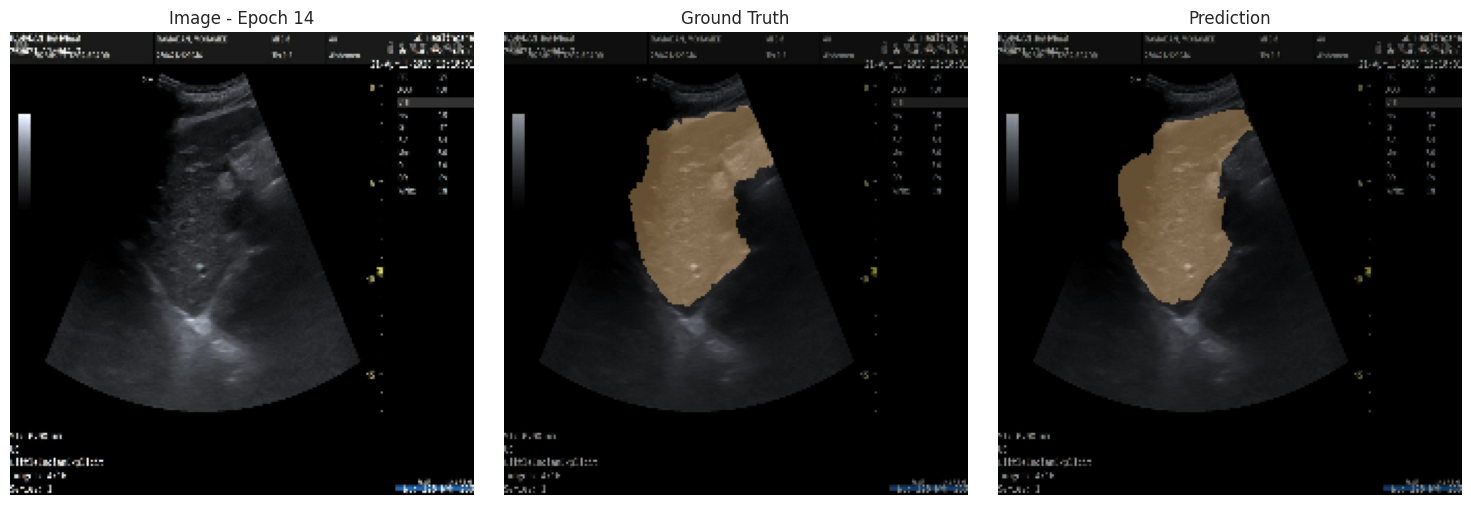

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 711ms/step - IoU: 0.4294 - accuracy: 0.9575 - loss: 0.1037 - val_IoU: 0.4314 - val_accuracy: 0.9558 - val_loss: 0.1074
Epoch 15/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - IoU: 0.4303 - accuracy: 0.9593 - loss: 0.0972

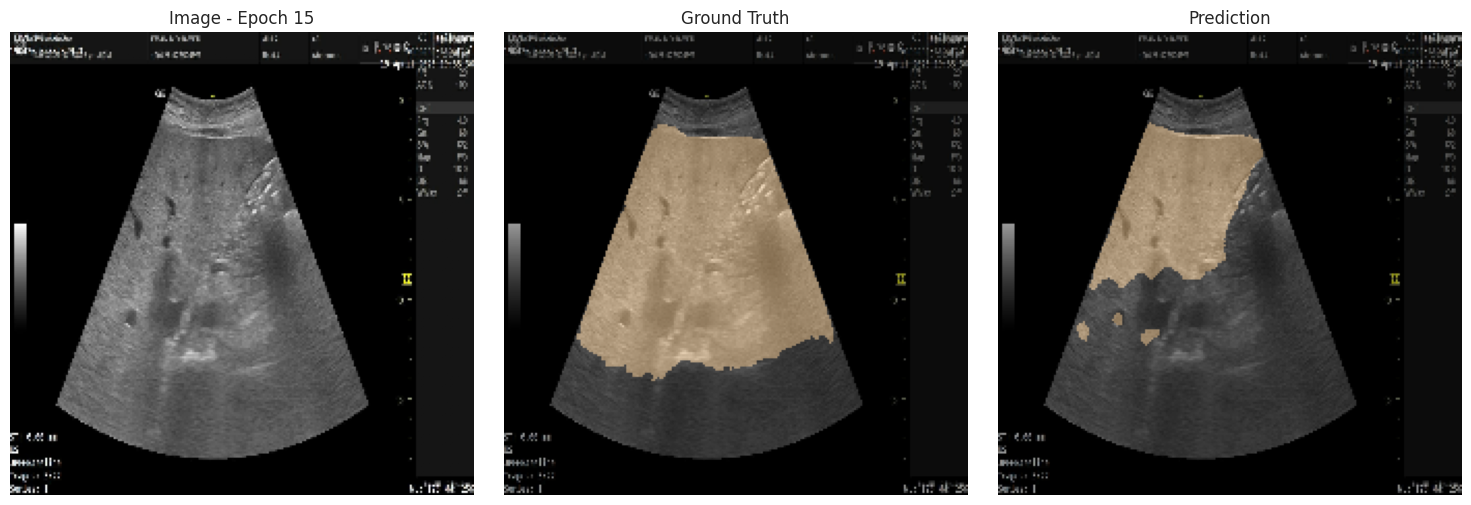

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 721ms/step - IoU: 0.4295 - accuracy: 0.9581 - loss: 0.1007 - val_IoU: 0.4314 - val_accuracy: 0.9526 - val_loss: 0.1061
Epoch 16/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - IoU: 0.4290 - accuracy: 0.9581 - loss: 0.1009

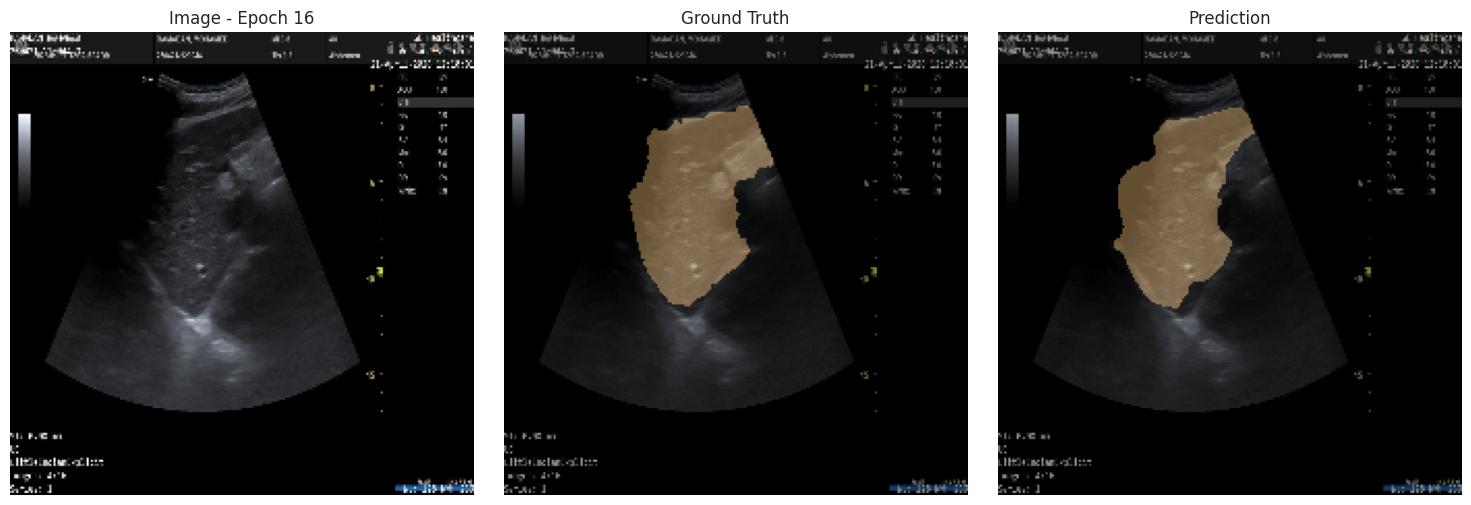

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 713ms/step - IoU: 0.4294 - accuracy: 0.9589 - loss: 0.0983 - val_IoU: 0.4314 - val_accuracy: 0.9535 - val_loss: 0.1078
Epoch 17/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - IoU: 0.4283 - accuracy: 0.9604 - loss: 0.0953

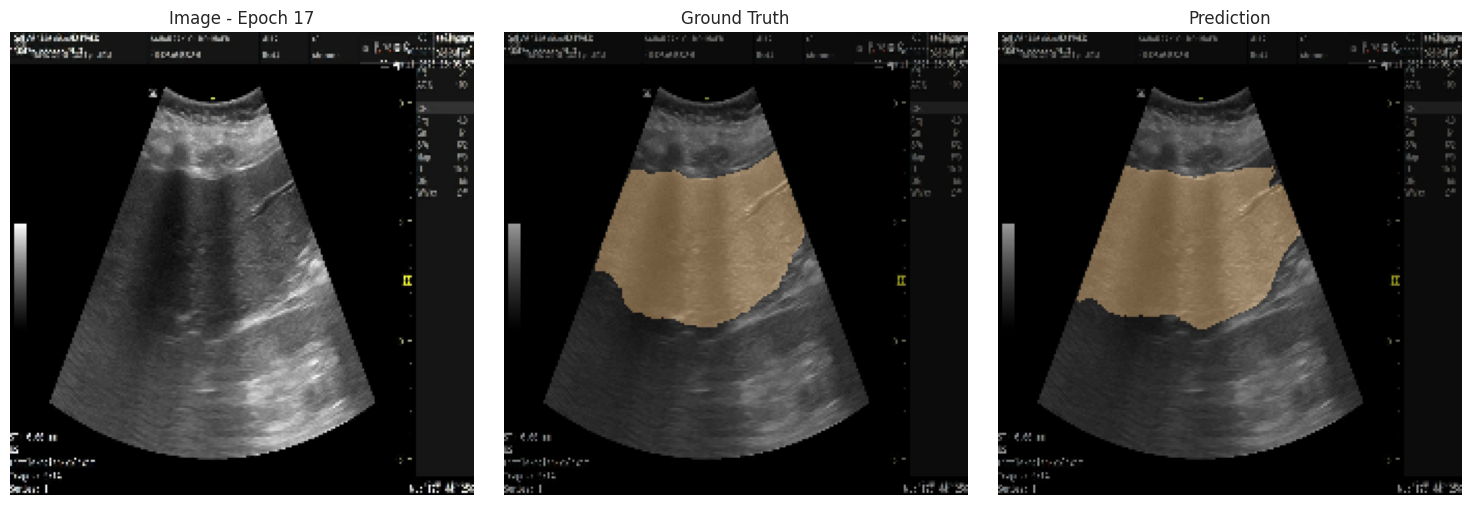

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 712ms/step - IoU: 0.4294 - accuracy: 0.9606 - loss: 0.0958 - val_IoU: 0.4314 - val_accuracy: 0.9540 - val_loss: 0.1092
Epoch 18/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - IoU: 0.4306 - accuracy: 0.9610 - loss: 0.0941

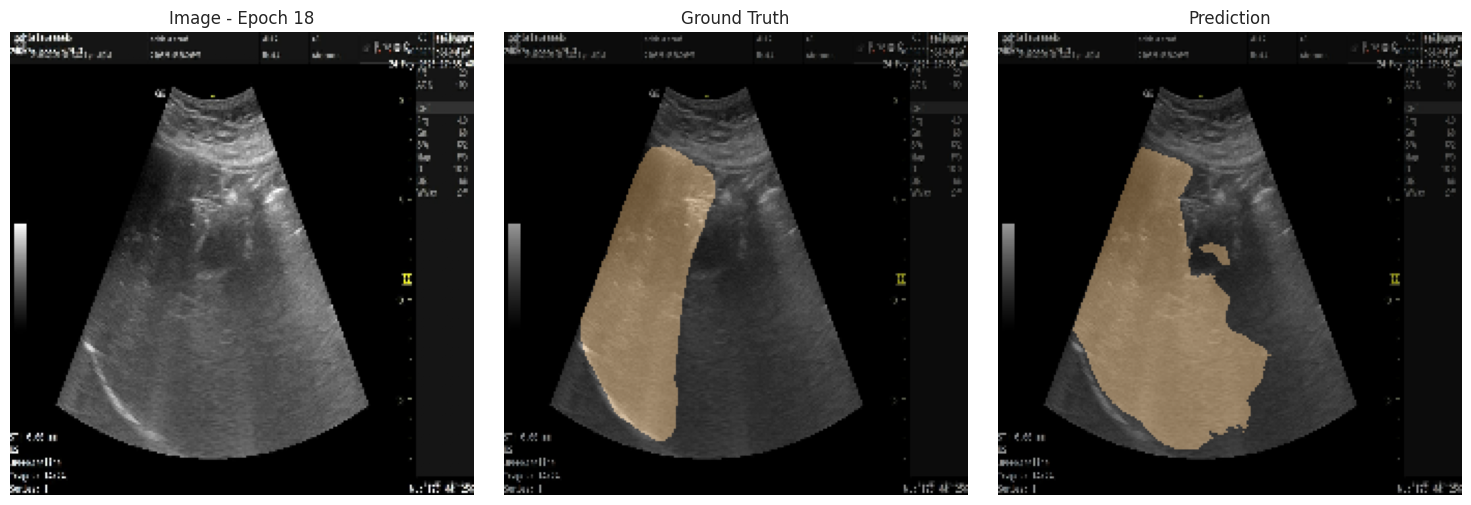

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 722ms/step - IoU: 0.4294 - accuracy: 0.9608 - loss: 0.0954 - val_IoU: 0.4314 - val_accuracy: 0.9566 - val_loss: 0.1030
Epoch 19/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - IoU: 0.4301 - accuracy: 0.9622 - loss: 0.0893

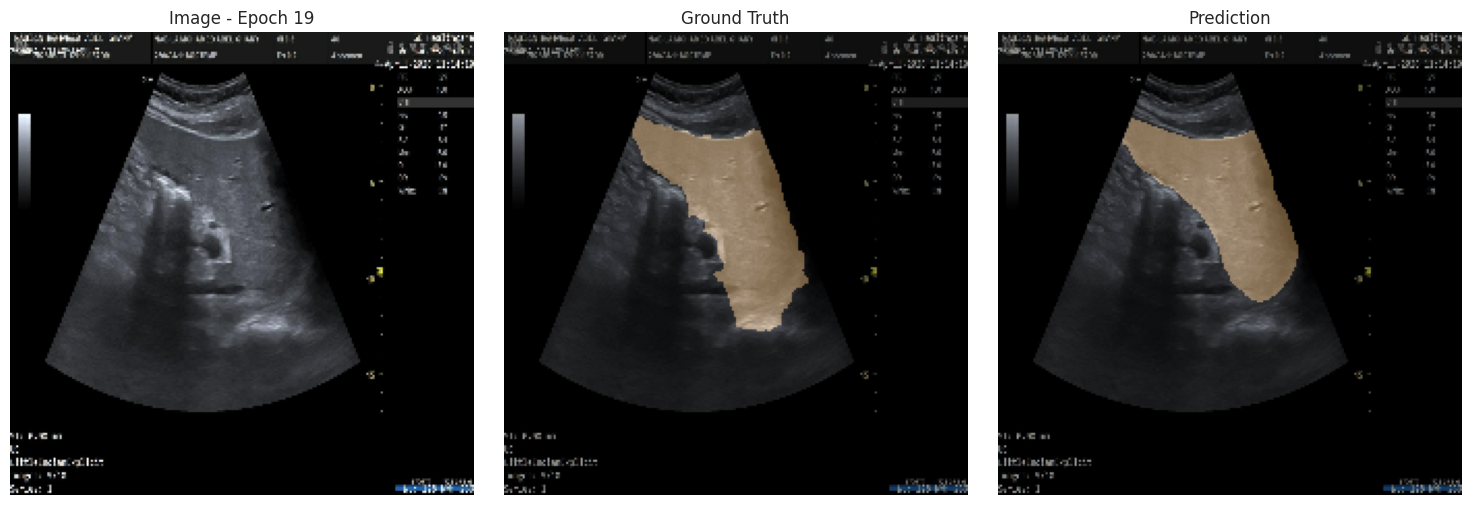

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 720ms/step - IoU: 0.4295 - accuracy: 0.9616 - loss: 0.0937 - val_IoU: 0.4314 - val_accuracy: 0.9582 - val_loss: 0.1029
Epoch 20/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - IoU: 0.4291 - accuracy: 0.9625 - loss: 0.0896

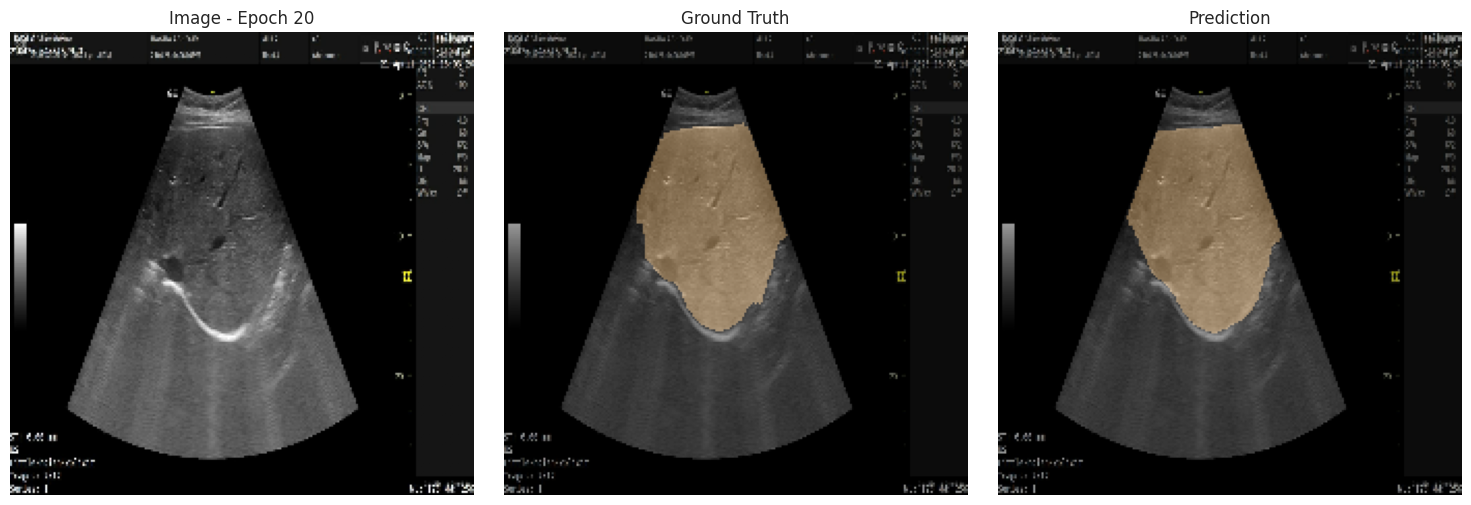

58/58 ━━━━━━━━━━━━━━━━━━━━ 48s 713ms/step - IoU: 0.4295 - accuracy: 0.9622 - loss: 0.0915 - val_IoU: 0.4314 - val_accuracy: 0.9559 - val_loss: 0.1068


In [25]:
# Training
results = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=cb
)

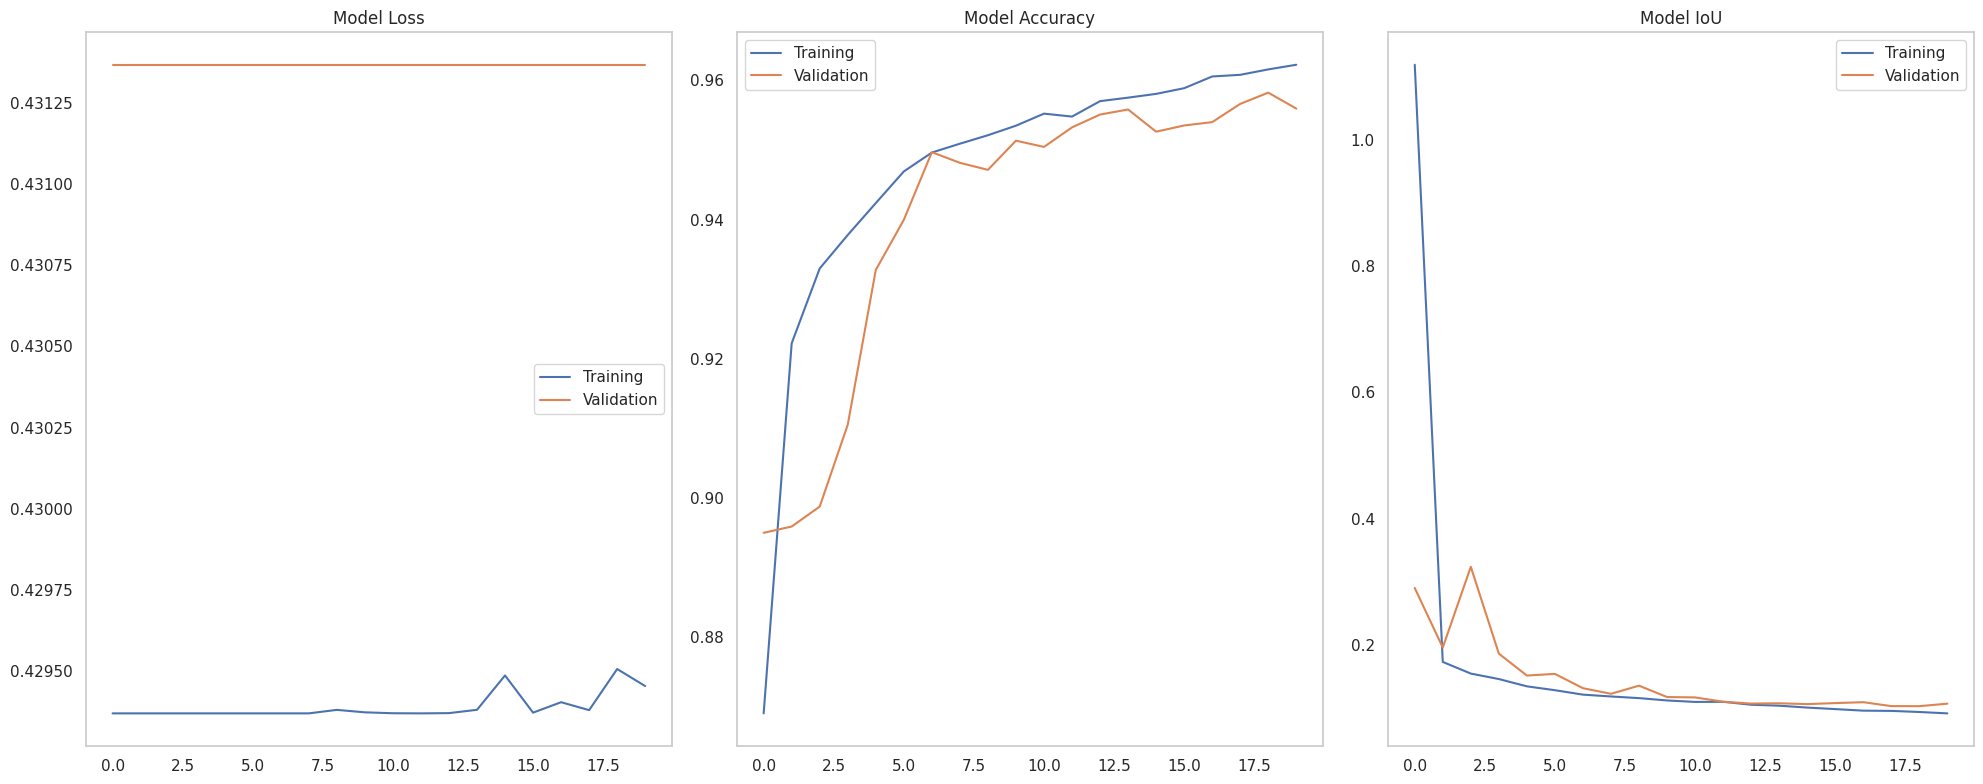

In [26]:
loss, accuracy, iou, val_loss, val_accuracy, val_iou = results.history.values()
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.title("Model Loss")
plt.plot(loss, label="Training")
plt.plot(val_loss, label="Validation")
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.title("Model Accuracy")
plt.plot(accuracy, label="Training")
plt.plot(val_accuracy, label="Validation")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.title("Model IoU")
plt.plot(iou, label="Training")
plt.plot(val_iou, label="Validation")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

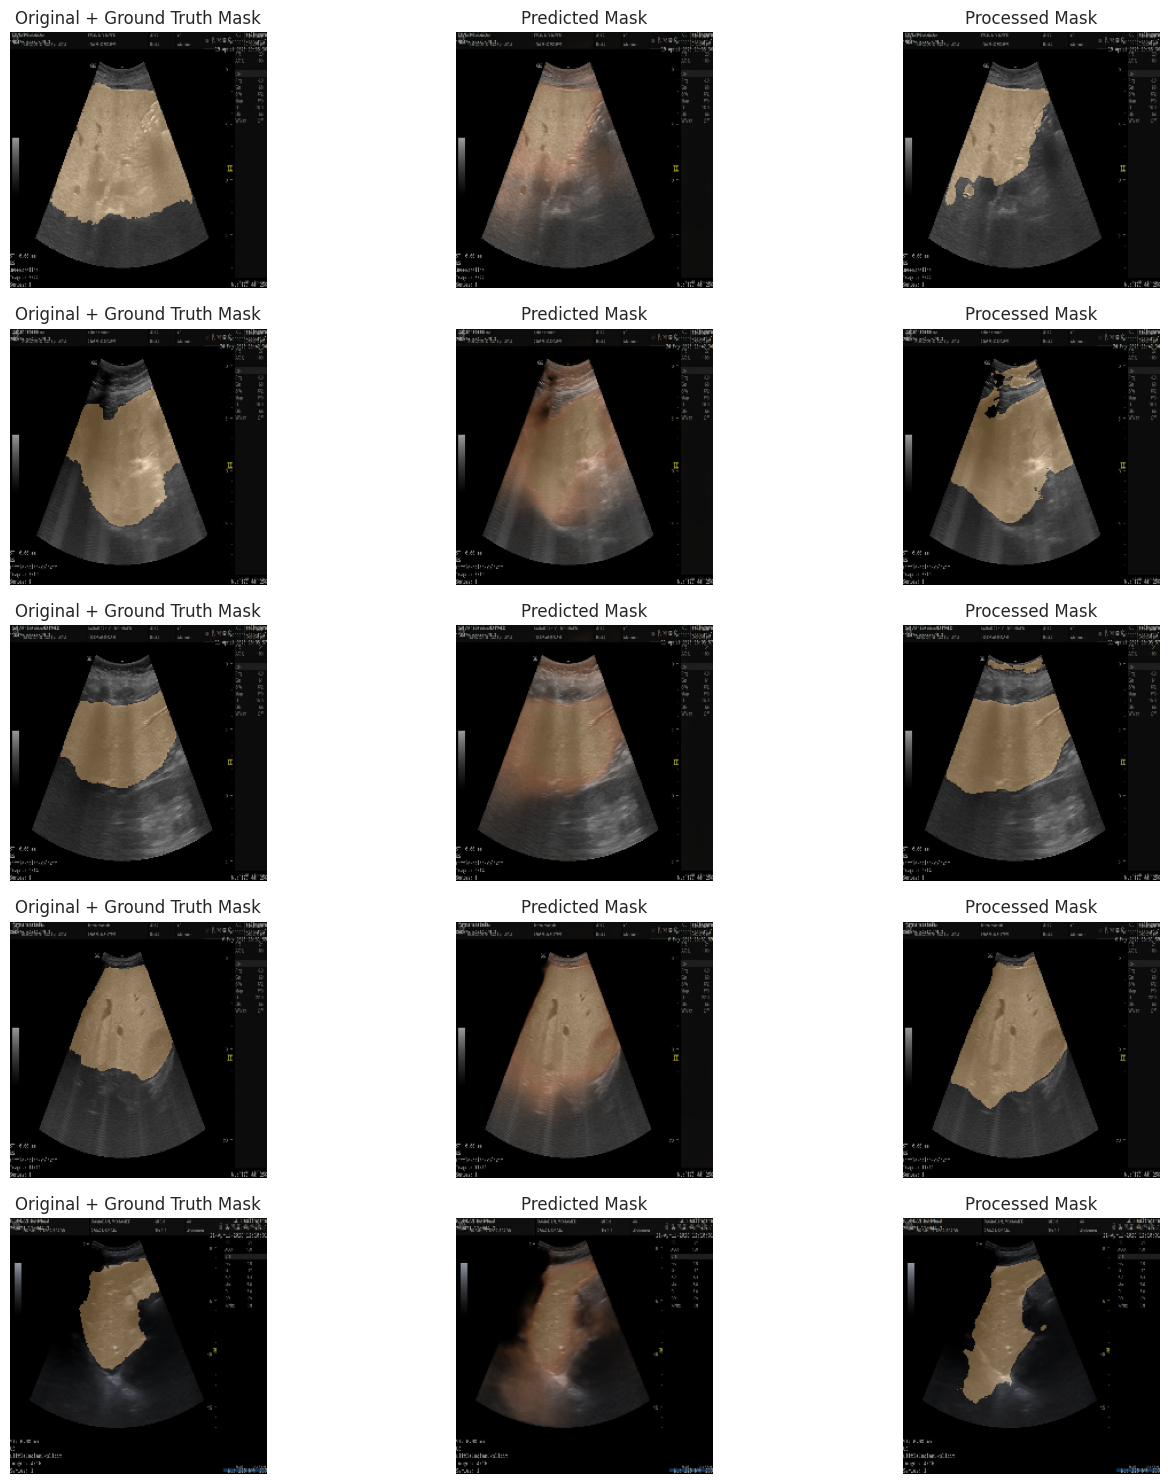

In [27]:
plt.figure(figsize=(15, 15))
images, masks = next(iter(validation_ds))
num_images = min(5, images.shape[0])

for i in range(num_images):

    image = images[i]
    mask = masks[i]

    # Predict
    pred_mask = model.predict(
        image[np.newaxis, ...],
        verbose=0
    )[0]
    plt.subplot(num_images, 3, i * 3 + 1)

    show_mask(
        image,
        mask,
        cmap="copper",
        alpha=0.4
    )

    plt.title("Original + Ground Truth Mask")
    plt.subplot(num_images, 3, i * 3 + 2)

    show_mask(
        image,
        pred_mask,
        cmap="copper",
        alpha=0.4
    )

    plt.title("Predicted Mask")

    pred_mask_binary = (
        pred_mask > 0.5
    ).astype(np.float32)

    plt.subplot(num_images, 3, i * 3 + 3)

    show_mask(
        image,
        pred_mask_binary,
        cmap="copper",
        alpha=0.4
    )

    plt.title("Processed Mask")

plt.savefig(
    "segmentation_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [28]:
history = results  

print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

if 'accuracy' in history.history:
    print("Final Training Accuracy:", history.history['accuracy'][-1])
    print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Loss: 0.09147918969392776
Final Validation Loss: 0.10684695839881897
Final Training Accuracy: 0.9622377157211304
Final Validation Accuracy: 0.9559400677680969


In [29]:
with open("training_results.json", "w") as f:
    json.dump(history.history, f, indent=4)

In [30]:
model.save("AttentionCustomUNet.keras")